## Air_Prediction_Implemetation

# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,zero_one_loss
from sklearn.svm import SVC
import warnings as w
w.filterwarnings('ignore')

# Read The Data

In [2]:
df = pd.read_csv(r"C:\Users\crao7\OneDrive\Desktop\AQI_Dataset.csv")
df.head(5)

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,NaN,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


# Check The Missing Value 

In [3]:
df.isnull().sum()

Temperature                       0
Humidity                          0
PM2.5                            16
PM10                              0
NO2                              12
SO2                               0
CO                                0
Proximity_to_Industrial_Areas    11
Population_Density                0
Air Quality                       0
dtype: int64

# Fill The Missing Value

In [4]:
pm2 = df['PM2.5'].median()
df['PM2.5'] = df['PM2.5'].fillna(pm2)

no2 = df['NO2'].median()
df['NO2'] = df['NO2'].fillna(no2)

pia = df['Proximity_to_Industrial_Areas'].median()
df['Proximity_to_Industrial_Areas'] = df['Proximity_to_Industrial_Areas'].fillna(pia)


# Basic Information Of data

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


In [7]:
print(df.describe())

       Temperature     Humidity        PM2.5         PM10          NO2  \
count  5000.000000  5000.000000  5000.000000  5000.000000  5000.000000   
mean     30.029020    70.056120    20.121620    30.218360    26.408740   
std       6.720661    15.863577    24.527239    27.349199     8.889078   
min      13.400000    36.000000     0.000000    -0.200000     7.400000   
25%      25.100000    58.300000     4.675000    12.300000    20.100000   
50%      29.000000    69.800000    12.000000    21.700000    25.300000   
75%      34.000000    80.300000    26.025000    38.100000    31.800000   
max      58.600000   128.100000   295.000000   315.800000    64.900000   

               SO2           CO  Proximity_to_Industrial_Areas  \
count  5000.000000  5000.000000                    5000.000000   
mean     10.014820     1.500354                       8.422440   
std       6.750303     0.546027                       3.605627   
min      -6.200000     0.650000                       2.500000   
25%

# Perform Exploratory Data Analysis(EDA)

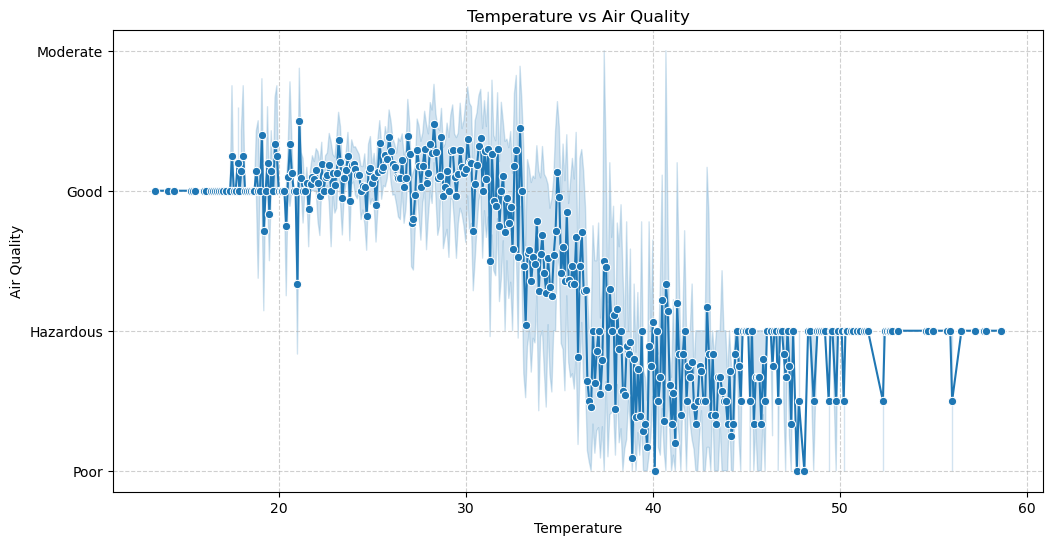

In [8]:
plt.figure(figsize=(12,6))
sns.lineplot(x='Temperature', y='Air Quality', data=df, marker='o')
plt.title("Temperature vs Air Quality")
plt.xlabel("Temperature")
plt.ylabel("Air Quality")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [9]:
df.head(2)

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate


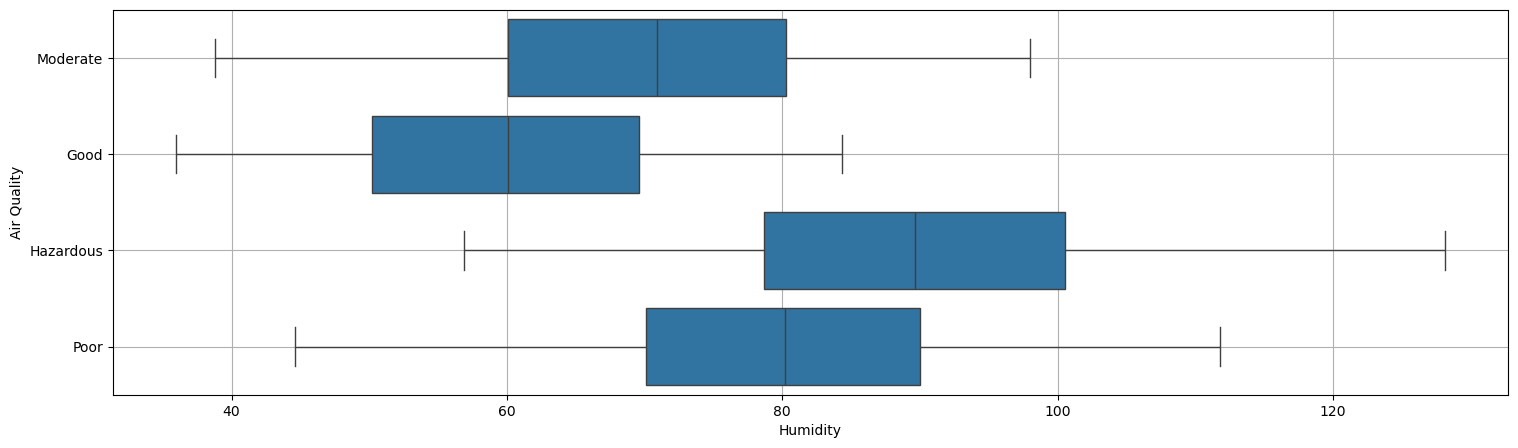

In [10]:
plt.figure(figsize = (18,5))
sns.boxplot(x = 'Humidity', y = 'Air Quality', data = df)
plt.grid()
plt.show()


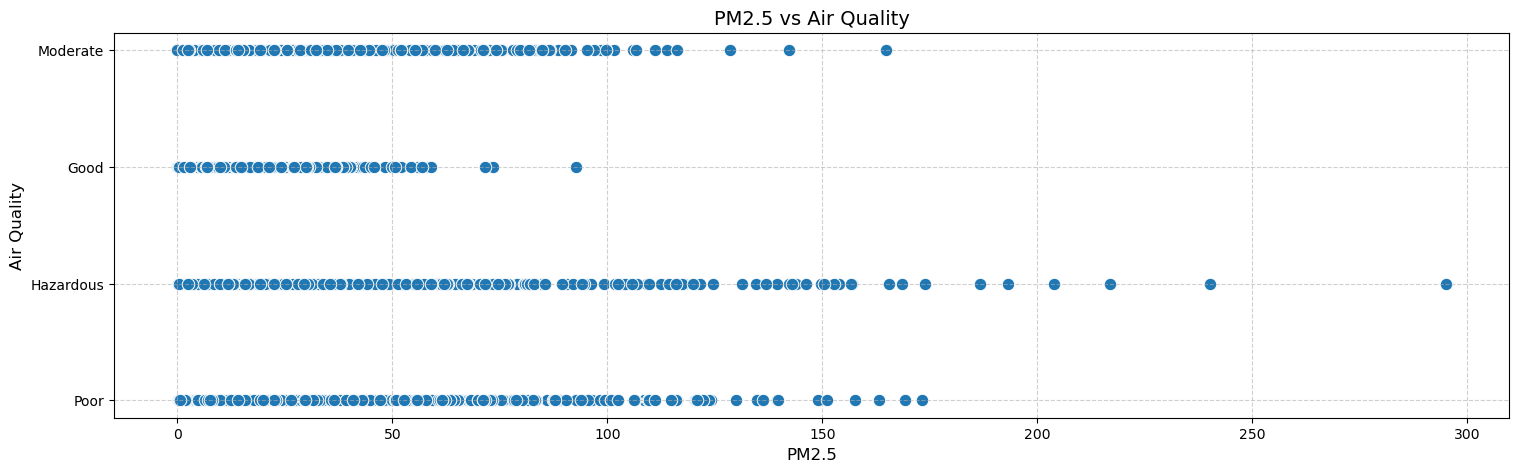

In [11]:
plt.figure(figsize=(18,5))
sns.scatterplot(x='PM2.5', y='Air Quality', data=df, s=80)

plt.title("PM2.5 vs Air Quality", fontsize=14)
plt.xlabel("PM2.5", fontsize=12)
plt.ylabel("Air Quality", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

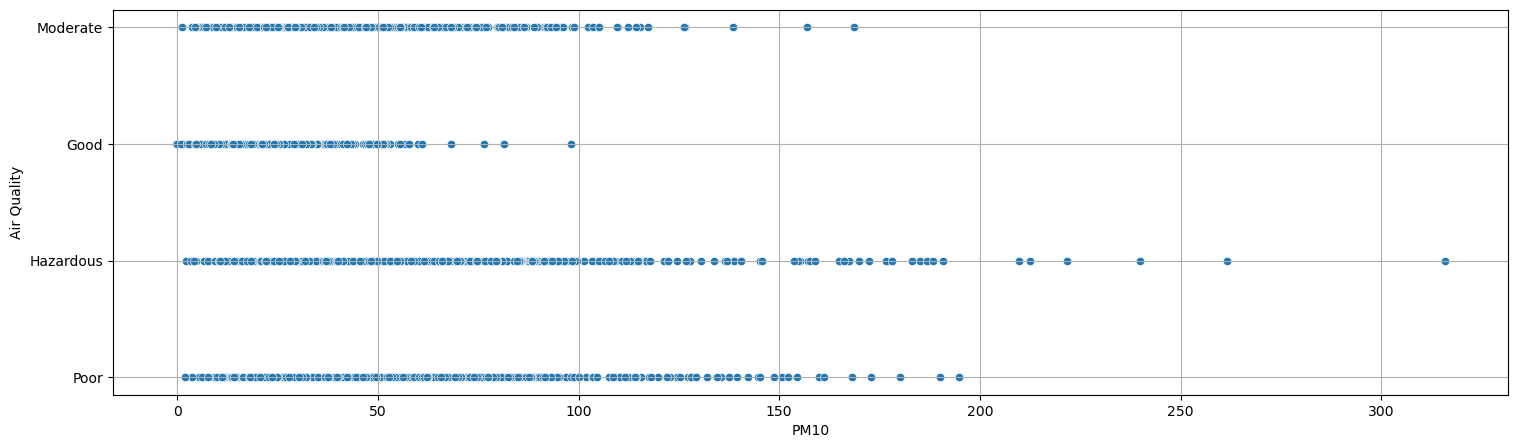

In [12]:
plt.figure(figsize = (18,5))
sns.scatterplot(x = 'PM10', y = 'Air Quality', data = df)
plt.grid()
plt.show()

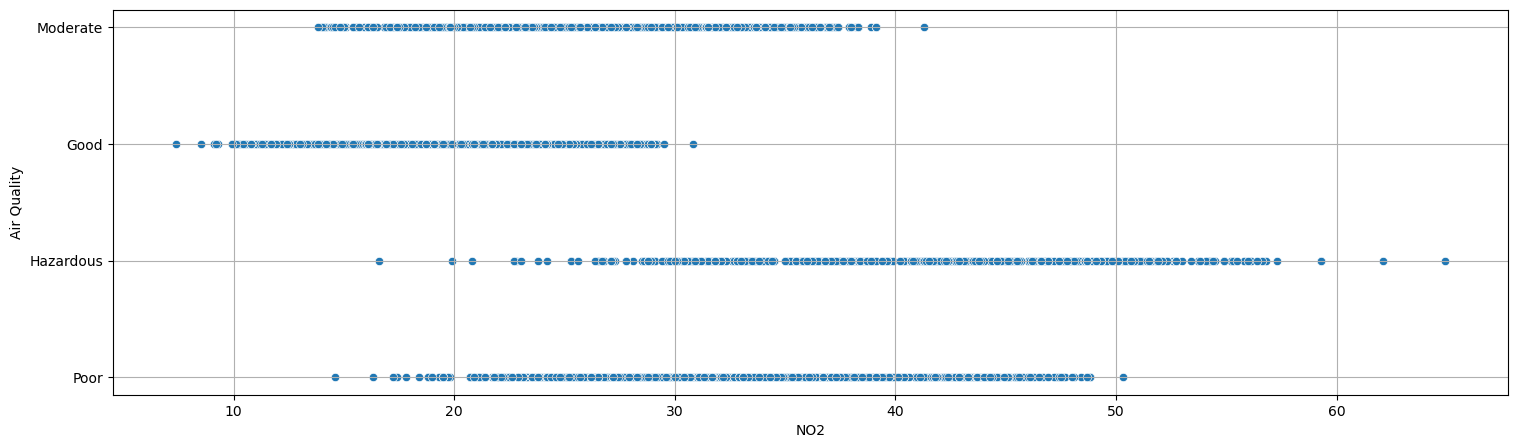

In [13]:
plt.figure(figsize = (18,5))
sns.scatterplot(x = 'NO2', y = 'Air Quality', data = df)
plt.grid()
plt.show()

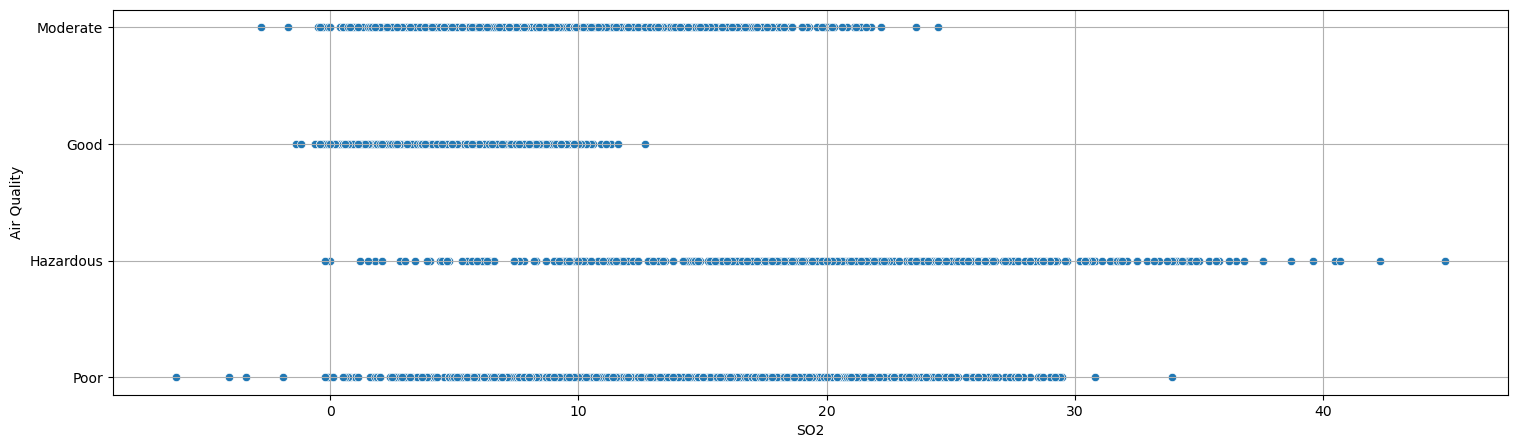

In [14]:
plt.figure(figsize = (18,5))
sns.scatterplot(x = 'SO2', y = 'Air Quality', data = df)
plt.grid()
plt.show()

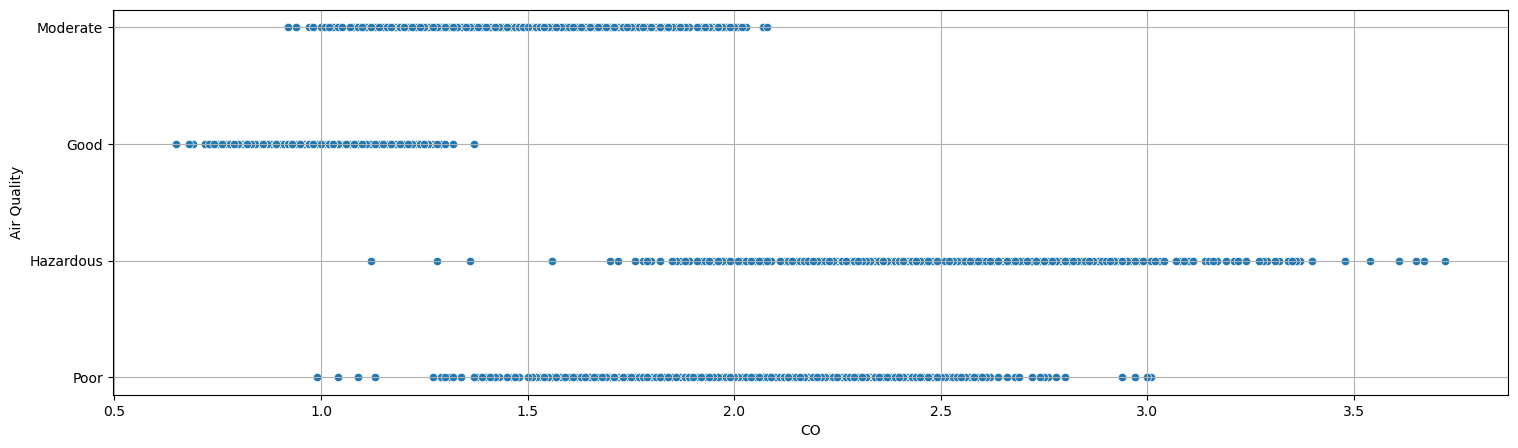

In [15]:
plt.figure(figsize = (18,5))
sns.scatterplot(x = 'CO', y = 'Air Quality', data = df)
plt.grid()
plt.show()

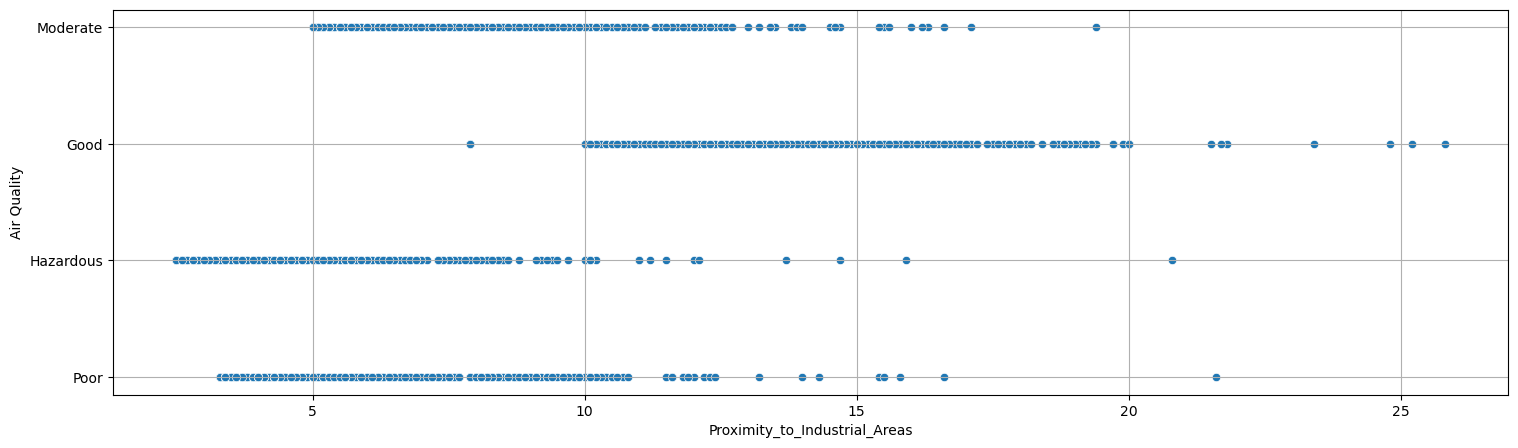

In [16]:
plt.figure(figsize = (18,5))
sns.scatterplot(x = 'Proximity_to_Industrial_Areas', y = 'Air Quality', data = df)
plt.grid()
plt.show()

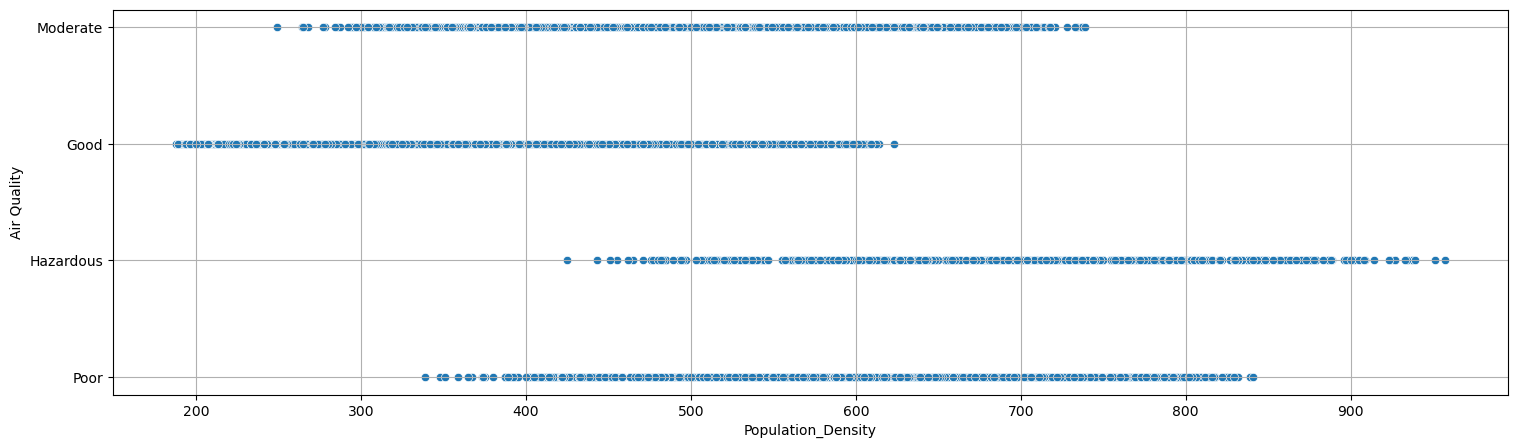

In [17]:
plt.figure(figsize = (18,5))
sns.scatterplot(x = 'Population_Density', y = 'Air Quality', data = df)
plt.grid()
plt.show()

# Separate Input And Output Column

In [18]:
x = df.drop(columns = "Air Quality")
y = df['Air Quality']

In [19]:
x.columns

Index(['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO',
       'Proximity_to_Industrial_Areas', 'Population_Density'],
      dtype='object')

# Encode The Output Column Using Label Encoder

In [20]:
le = LabelEncoder()
y = le.fit_transform(y)
x = pd.get_dummies(x, drop_first=True)
x.columns

Index(['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO',
       'Proximity_to_Industrial_Areas', 'Population_Density'],
      dtype='object')

# Splitting The Dataset Into Training And Testing Sets

In [21]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Scaling The Train and Test Data

In [22]:
sc = StandardScaler()

x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.fit_transform(x_test)

# Random Forest Model Preparation

In [23]:
RF = RandomForestClassifier(n_estimators=100)
RF.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Predict For Test Data

In [24]:
y_pred = RF.predict(x_test)
y_pred

array([1, 0, 2, 1, 0, 1, 0, 0, 0, 2, 2, 0, 3, 0, 2, 0, 0, 0, 2, 3, 0, 0,
       3, 2, 0, 3, 0, 0, 2, 2, 0, 3, 3, 2, 2, 3, 2, 2, 2, 0, 3, 2, 1, 0,
       0, 2, 2, 3, 0, 0, 2, 0, 0, 0, 0, 2, 1, 2, 3, 0, 0, 0, 0, 2, 0, 3,
       3, 0, 2, 2, 0, 0, 3, 0, 0, 2, 2, 2, 0, 0, 0, 3, 3, 0, 2, 2, 1, 2,
       2, 3, 2, 0, 0, 3, 3, 2, 2, 0, 3, 0, 1, 2, 2, 2, 1, 0, 0, 0, 2, 0,
       2, 2, 2, 0, 2, 3, 1, 0, 0, 0, 2, 2, 3, 2, 3, 0, 2, 2, 0, 0, 2, 0,
       3, 0, 2, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2, 2, 1, 0, 2, 2, 3, 3, 3, 0,
       0, 3, 2, 2, 2, 2, 1, 0, 2, 1, 3, 2, 0, 0, 0, 0, 2, 3, 0, 1, 0, 0,
       0, 2, 0, 3, 3, 0, 2, 0, 0, 3, 0, 0, 0, 0, 1, 1, 2, 1, 2, 2, 1, 1,
       3, 3, 0, 0, 2, 2, 0, 0, 0, 2, 0, 0, 0, 0, 3, 2, 2, 2, 2, 2, 0, 1,
       0, 2, 0, 2, 0, 2, 1, 1, 2, 0, 0, 0, 0, 0, 0, 3, 0, 3, 3, 2, 2, 0,
       2, 1, 0, 2, 0, 0, 0, 0, 2, 2, 0, 1, 3, 3, 0, 0, 1, 3, 0, 2, 0, 1,
       0, 2, 3, 3, 2, 0, 2, 2, 2, 0, 1, 1, 2, 0, 3, 0, 1, 0, 0, 3, 2, 0,
       3, 2, 0, 2, 2, 1, 0, 0, 2, 2, 2, 2, 2, 0, 2,

# Perform The Both ACC and Zero_one_lose

In [25]:
rf_acc = accuracy_score(y_test,y_pred)
rf_acc

0.96

In [26]:
rf_error = zero_one_loss(y_test,y_pred)
rf_error

0.040000000000000036

# Support Vector Machine Model Preparation

In [27]:
svc = SVC()
svc.fit(x_train_scaled,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


# Predict The SVC data

In [28]:
svc_pred = svc.predict(x_test_scaled)
svc_pred

array([1, 0, 2, 1, 0, 1, 0, 0, 0, 2, 3, 0, 1, 0, 2, 0, 0, 0, 2, 3, 0, 0,
       3, 2, 0, 3, 0, 0, 2, 2, 0, 3, 3, 2, 2, 2, 2, 2, 2, 0, 3, 2, 1, 0,
       0, 3, 2, 3, 0, 0, 2, 0, 0, 0, 0, 2, 1, 2, 3, 0, 0, 0, 0, 2, 0, 3,
       3, 0, 2, 2, 0, 0, 3, 0, 0, 2, 2, 2, 0, 0, 0, 1, 3, 0, 2, 2, 3, 2,
       2, 1, 2, 0, 0, 3, 3, 2, 2, 0, 3, 0, 1, 2, 3, 2, 1, 0, 0, 0, 2, 0,
       2, 2, 2, 0, 2, 3, 1, 0, 0, 0, 2, 2, 2, 2, 3, 0, 2, 2, 0, 0, 2, 0,
       3, 0, 2, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2, 2, 1, 0, 2, 2, 3, 3, 2, 0,
       0, 3, 2, 2, 2, 2, 1, 0, 2, 1, 3, 2, 0, 0, 0, 0, 2, 3, 0, 1, 0, 0,
       0, 2, 0, 3, 3, 0, 2, 0, 0, 3, 0, 0, 0, 0, 1, 1, 2, 3, 2, 2, 1, 3,
       3, 3, 0, 0, 2, 2, 0, 0, 0, 2, 0, 0, 0, 0, 3, 2, 2, 2, 2, 3, 0, 1,
       0, 2, 0, 2, 0, 2, 1, 1, 2, 0, 0, 0, 0, 0, 0, 3, 0, 3, 3, 2, 2, 0,
       2, 1, 0, 2, 0, 0, 0, 0, 2, 2, 0, 1, 3, 3, 0, 0, 1, 3, 0, 2, 0, 3,
       0, 2, 3, 3, 2, 0, 2, 2, 2, 0, 3, 1, 2, 0, 3, 0, 1, 0, 0, 3, 2, 0,
       3, 2, 0, 2, 2, 1, 0, 0, 2, 2, 2, 2, 2, 0, 2,

In [29]:
svc_acc = accuracy_score(y_test,svc_pred)
svc_acc

0.939

In [30]:
svc_error = zero_one_loss(y_test,svc_pred)
svc_error

0.061000000000000054

In [31]:
df.head(2)

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate


# Scaling The New Data 

In [32]:
new_data = pd.DataFrame([[45.4,66.4,6.8,19.0,67.9,8.7,1.67,7.9,334]])                 
data_scaled = sc.transform(new_data)
data_scaled

array([[ 2.33492367, -0.22442612, -0.55232543, -0.40382166,  4.60185361,
        -0.19254486,  0.2874734 , -0.13015104, -1.04721156]])

In [33]:
new_data_predict =svc.predict(data_scaled)
new_data_predict

array([1])

# Compare the Random_Forest and SVM

In [34]:
compare = pd.DataFrame({'Models':['Random Forest','SVM'],'accracy':[rf_acc,svc_acc],'Errors':[rf_error,svc_error]})
print(compare)


          Models  accracy  Errors
0  Random Forest    0.960   0.040
1            SVM    0.939   0.061


# GUI Implemetation For Air_Prediction

In [37]:
import pandas as pd
from IPython.display import display, HTML
from ipywidgets import *

# ==========================
# Feature names from dataset
# ==========================
feature_names = x.columns.tolist()

# ==========================
# Title
# ==========================
title = HTML("""
<div style="
    background:#1976D2;
    color:white;
    padding:15px;
    border-radius:10px;
    text-align:center;
    font-size:24px;
    font-weight:bold;
    width:500px;">
    Air Quality Prediction System
</div>
""")

# ==========================
# Create input boxes
# ==========================
input_widgets = []

for feature in feature_names:
    box = Text(
        description=feature,
        placeholder="Enter value",
        layout=Layout(width='450px'),
        style={'description_width': '180px'}
    )
    input_widgets.append(box)

# ==========================
# Output area
# ==========================
output = Output(
    layout=Layout(
        width='500px',
        border='1px solid #ccc',
        padding='10px',
        margin='10px'
    )
)

# ==========================
# Prediction function
# ==========================
def predict(btn):
    output.clear_output()
    values = []

    for widget in input_widgets:
        if widget.value.strip() == "":
            with output:
                display(HTML("""
                <div style="
                    color:red;
                    font-weight:bold;
                    text-align:center;">
                    Please fill all input fields.
                </div>
                """))
            return

        try:
            values.append(float(widget.value))
        except:
            with output:
                display(HTML("""
                <div style="
                    color:orange;
                    font-weight:bold;
                    text-align:center;">
                    Please enter numeric values only.
                </div>
                """))
            return

    # Create DataFrame
    input_df = pd.DataFrame([values], columns=feature_names)

    # Scale for SVM
    input_scaled = sc.transform(input_df)

    # Predictions
    rf_pred = le.inverse_transform(RF.predict(input_df))[0]
    svc_pred = le.inverse_transform(svc.predict(input_scaled))[0]

    # Show results
    
    with output:
        display(HTML(f"""
        <div style="
            background:white;
            padding:16px;
            border-radius:10px;
            border:1px solid #ccc;
            box-shadow:0 2px 8px rgba(0,0,0,0.08);">

            <h3 style="
                color:#1976D2;
                text-align:center;
                margin-bottom:12px;">
                Prediction Result
            </h3>

            <table style="
                width:100%;
                border-collapse:collapse;
                font-size:16px;
                background:white;">
                <tr style="background:#e3f2fd;">
                    <th style="padding:12px; border:1px solid #bbdefb; text-align:left; color:#0d47a1;">
                        Model
                    </th>
                    <th style="padding:12px; border:1px solid #bbdefb; text-align:left; color:#0d47a1;">
                        Prediction
                    </th>
                </tr>
                <tr>
                    <td style="padding:12px; border:1px solid #ccc; font-weight:bold; color:#1b5e20;">
                        Random Forest
                    </td>
                    <td style="padding:12px; border:1px solid #ccc; color:#2e7d32; font-weight:bold;">
                        {rf_pred}
                    </td>
                </tr>
                <tr>
                    <td style="padding:12px; border:1px solid #ccc; font-weight:bold; color:#0d47a1;">
                        SVM
                    </td>
                    <td style="padding:12px; border:1px solid #ccc; color:#1565c0; font-weight:bold;">
                        {svc_pred}
                    </td>
                </tr>
            </table>
        </div>
        """))
# ==========================
# Predict button
# ==========================
predict_btn = Button(
    description="Predict Air Quality",
    button_style='success',
    icon="check",
    layout=Layout(width='220px', height='40px')
)

predict_btn.on_click(predict)

# ==========================
# Input section
# ==========================
input_section = VBox(
    input_widgets,
    layout=Layout(
        border='1px solid #ccc',
        padding='20px',
        width='500px',
        margin='10px'
    )
)

# ==========================
# Display GUI
# ==========================
display(
    VBox(
        [
            title,
            input_section,
            predict_btn,
            output
        ],
        layout=Layout(
            align_items='center',
            padding='20px'
        )
    )
)

In [36]:
#29.8	59.1	5.2	17.9	18.9	9.2	1.72	6.3	319	